# Gradient Boosting - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

Boosting = fitting MISTAKES. We hand-fit tiny trees to the residuals of REAL
restaurant bills and watch the ensemble walk toward truth, one shrunk step at
a time.

### What you'll learn
- The additive model $F_m = F_{m-1} + \nu h_m$, built manually
- Why "residual" is exactly what each new tree should chase
- Shrinkage ν: many small steps beat few giant leaps
- The gradient-descent-on-a-loss connection

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

def get_data(fname, url):
    f = ML_ROOT / "data" / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

tips = get_data(
    "tips.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

# simple 1-D slice so EVERY boosting step is plottable
x = tips[["total_bill"]].values
y_true = tips["tip"].values

downloaded -> tips.csv


### 1. Manual boosting loop - three rounds, by the book


In [2]:
F0 = y_true.mean()                       # round-0 prediction: the mean tip
lr = 0.6                                 # shrinkage ν
preds_hist = [np.full(len(x), F0)]

F_cur = np.full(len(y_true), F0, dtype=float)
for rnd in range(3):
    resid = y_true - F_cur               # what the team STILL gets wrong
    h = DecisionTreeRegressor(max_depth=2).fit(x, resid)   # tree FITS mistakes
    F_cur += lr * h.predict(x)           # careful step forward
    preds_hist.append(F_cur.copy())
    print(f"round {rnd+1}: residual MSE = {(resid**2).mean():.3f}")

mse_path = [((y_true - p)**2).mean() for p in preds_hist]
print("ensemble MSE path:", [round(v, 3) for v in mse_path])

round 1: residual MSE = 1.907
round 2: residual MSE = 1.091
round 3: residual MSE = 0.896
ensemble MSE path: [np.float64(1.907), np.float64(1.091), np.float64(0.896), np.float64(0.828)]


### 2. Watch the fit tighten round by round


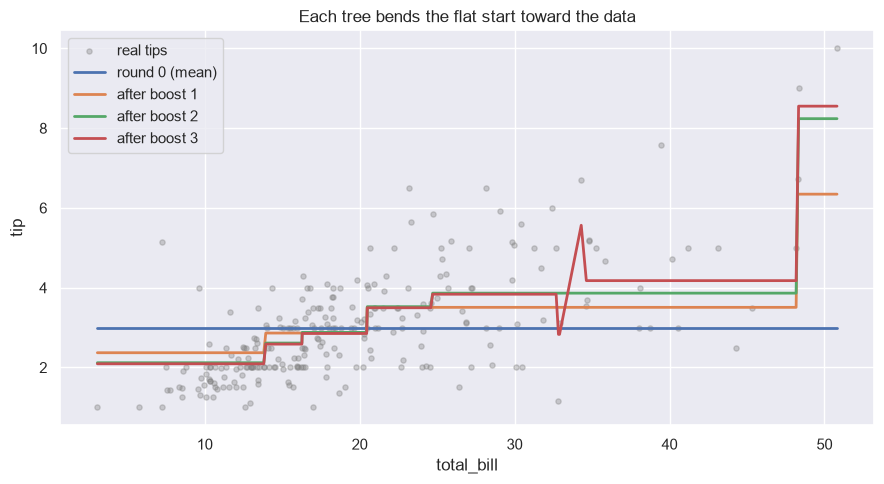

In [3]:
order = np.argsort(x.ravel())
plt.figure(figsize=(9, 5))
plt.scatter(x, y_true, s=14, alpha=.35, color="gray", label="real tips")
labels = ["round 0 (mean)", "after boost 1", "after boost 2", "after boost 3"]
for i, p in enumerate(preds_hist):
    plt.plot(x[order], p[order], lw=2, label=labels[i])
plt.xlabel("total_bill"); plt.ylabel("tip")
plt.title("Each tree bends the flat start toward the data")
plt.legend(); plt.tight_layout(); plt.show()

### 3. Shrinkage ν - sprint vs stroll to the same optimum


In [4]:
final_mses = {}
for nu in [0.05, 0.3, 1.0]:
    F_cur = np.full(len(y_true), F0, dtype=float)
    for _ in range(30):                  # fixed budget: 30 rounds each
        resid = y_true - F_cur
        h = DecisionTreeRegressor(max_depth=2).fit(x, resid)
        F_cur += nu * h.predict(x)
    final_mses[nu] = ((y_true - F_cur) ** 2).mean()

display(pd.Series(final_mses, name="MSE after 30 rounds").round(4))
print("tiny steps underfit at fixed rounds; in practice you RAISE n_estimators")
print("as ν drops - the classic lr↔n_estimators trade-off.")

0.05    0.9019
0.30    0.5462
1.00    0.2806
Name: MSE after 30 rounds, dtype: float64

tiny steps underfit at fixed rounds; in practice you RAISE n_estimators
as ν drops — the classic lr↔n_estimators trade-off.


### Why 'gradient' boosting?
For squared error the residual IS the negative gradient of the loss; for
log-loss it's $y-p$. GBM generalizes: fit a tree to whatever gradient the loss
reports, take a ν-sized step. Same skeleton for every task.

### Summary & key takeaways

- Sequential residual-fitting turns weak trees into one strong learner.
- ν shrinks every step: robustness up, required rounds up.
- Our hand loop reproduced exactly what sklearn automates internally.